# Text Feature Signal Evaluation

**Chapter 10: Text Feature Engineering**
**Section Reference**: See Section 10.5 for practitioner workflow and alpha factor design

**Docker image**: `ml4t`

## Purpose
This notebook evaluates **text-derived alpha signals** produced by
[`07_news_return_signals`](07_news_return_signals.ipynb) using standard factor diagnostics:
- Daily cross-sectional Information Coefficient (Spearman rank correlation)
- ICIR and t-stats for robustness
- Quintile and long-short (Q5 - Q1) spread analysis

## Data Contract
- **Input**: `output/fnspid/news_features.parquet` (from notebook 07)
  - Contains forward returns (fwd_ret_1d, fwd_ret_5d, fwd_ret_20d) already aligned
  - No additional price data or label computation needed
- **Output**: `output/text_evaluation/text_signal_summary.parquet`

## Learning Objectives
After completing this notebook, you will be able to:
- Evaluate NLP-derived alpha signals using standard factor analysis
- Compute daily IC, ICIR, and t-statistics for text signals
- Analyze quintile spreads and long-short returns
- Understand the predictive power of text-based factors

## Prerequisites
- Section 10.5 of the chapter (alpha-factor evaluation: IC, ICIR, quintile spread).
- `news_features.parquet` produced by `07_news_return_signals.py`.

## Related Notebooks
- `07_news_return_signals.py` — produces the text features evaluated here.
- `09_filing_text_signals.py` — analogous IC analysis for 10-Q filing signals.

## Signals Evaluated
| Signal | Description | Expected Effect |
|--------|-------------|-----------------|
| weighted_surprise | News surprise × sentiment direction | Positive (directional information) |
| sentiment_mean | Average daily sentiment | Positive (bullish → positive returns) |
| sentiment_momentum | Change in sentiment vs baseline | Positive (improving sentiment) |
| coverage_count | Article frequency | Ambiguous (attention effect) |

In [1]:
"""Text Feature Signal Evaluation - Evaluate NLP-derived alpha signals."""

import json
import warnings
from collections.abc import Iterator
from dataclasses import dataclass

import matplotlib.pyplot as plt
import numpy as np
import polars as pl
from scipy.stats import spearmanr

warnings.filterwarnings("ignore")

from utils.paths import get_output_dir
from utils.reproducibility import set_global_seeds

In [2]:
SEED = 42
MIN_ASSETS_PER_DAY = 5

In [3]:
# Reproducibility — set_global_seeds covers Python random / NumPy / Torch.
set_global_seeds(SEED)


@dataclass(frozen=True)
class EvalConfig:
    """Configuration for text signal evaluation."""

    horizons: tuple[int, ...] = (1, 5, 20)
    min_assets_per_day: int = 5
    quantiles: int = 5


# Paths using standard utilities
TEXT_INPUT_DIR = get_output_dir(8, "fnspid")
OUTPUT_DIR = get_output_dir(8, "text_evaluation")
CONFIG = EvalConfig(min_assets_per_day=MIN_ASSETS_PER_DAY)

## 1. Load Text Features from Notebook 07

Notebook 07 produces a complete dataset with:
- Text signals (weighted_surprise, sentiment_mean, etc.)
- Forward returns (fwd_ret_1d, fwd_ret_5d, fwd_ret_20d) already computed
- Proper look-ahead bias handling (signals lag returns by 1 day)

We do NOT recompute labels here—we use the dataset contract from notebook 07.

In [4]:
# Load text-derived features
text_features_path = TEXT_INPUT_DIR / "news_features.parquet"

if not text_features_path.exists():
    raise FileNotFoundError(
        f"Missing input: {text_features_path}\n\n"
        "Run notebook 07 first to generate this dataset:\n"
        "  python 08_text_feature_engineering/code/07_news_return_signals.py"
    )

text_features = pl.read_parquet(text_features_path)

if len(text_features) == 0:
    raise ValueError(
        f"Empty dataset: {text_features_path}\nNotebook 07 ran but produced no usable rows."
    )

print(f"Loaded {len(text_features):,} observations")
print(f"Columns: {text_features.columns}")

Loaded 15,778 observations
Columns: ['ticker', 'date', 'news_date', 'trade_date', 'news_surprise', 'sentiment_mean', 'sentiment_std', 'weighted_surprise', 'sentiment_momentum', 'coverage_count', 'fwd_ret_1d', 'fwd_ret_5d', 'fwd_ret_20d']


In [5]:
# Normalize schema from notebook 07


def normalize_schema(df: pl.DataFrame) -> pl.DataFrame:
    """
    Normalize the schema produced by notebook 07 to a canonical evaluation schema.

    Canonical requirements:
    - symbol: str (entity identifier)
    - timestamp: pl.Date (tradable date)
    - forward returns: fwd_ret_1d, fwd_ret_5d, fwd_ret_20d
    """
    # Normalize entity column to 'symbol'
    if "symbol" not in df.columns:
        for alt in ("ticker", "asset"):
            if alt in df.columns:
                df = df.rename({alt: "symbol"})
                break
        else:
            raise ValueError("Missing entity column. Expected 'symbol', 'ticker', or 'asset'.")

    # Normalize time column to 'timestamp'
    if "timestamp" not in df.columns:
        for alt in ("date", "trade_date"):
            if alt in df.columns:
                df = df.rename({alt: "timestamp"})
                break
        else:
            raise ValueError("Missing time column. Expected 'timestamp', 'date', or 'trade_date'.")

    # Parse date string if needed
    if df["timestamp"].dtype == pl.Utf8:
        df = df.with_columns(pl.col("timestamp").str.to_date().alias("timestamp"))

    # Verify forward return columns exist
    required_return_cols = {"fwd_ret_1d", "fwd_ret_5d", "fwd_ret_20d"}
    missing = required_return_cols - set(df.columns)
    if missing:
        raise ValueError(f"Missing forward return columns: {sorted(missing)}")

    return df


text_features = normalize_schema(text_features)
print(f"Date range: {text_features['timestamp'].min()} to {text_features['timestamp'].max()}")
print(f"Unique assets: {text_features['symbol'].n_unique()}")
text_features.head(10)

Date range: 2009-12-21 to 2017-11-16
Unique assets: 39


symbol,timestamp,news_date,trade_date,news_surprise,sentiment_mean,sentiment_std,weighted_surprise,sentiment_momentum,coverage_count,fwd_ret_1d,fwd_ret_5d,fwd_ret_20d
str,date,date,str,f64,f64,f64,f64,f64,i64,f64,f64,f64
"""ADBE""",2010-04-30,2010-04-29,"""2010-04-30""",0.222876,0.0,0.0,0.0,0.0,2,-0.000298,-0.035119,-0.045238
"""ADBE""",2010-05-04,2010-05-03,"""2010-05-04""",0.516712,0.0,0.0,0.0,-0.666667,1,-0.005432,0.019916,-0.006035
"""ADBE""",2010-05-06,2010-05-05,"""2010-05-06""",0.348653,0.0,0.0,0.0,0.0,1,-0.002155,0.059095,-0.027624
"""ADBE""",2010-05-12,2010-05-11,"""2010-05-12""",0.570604,0.0,0.0,0.0,0.0,1,-0.011207,-0.055172,-0.088506
"""ADBE""",2010-05-13,2010-05-12,"""2010-05-13""",0.822824,0.0,0.0,0.0,-1.0,1,-0.020052,-0.077594,-0.077884
"""ADBE""",2010-05-17,2010-05-14,"""2010-05-17""",0.363815,0.0,0.0,0.0,0.0,1,-0.015676,-0.064478,-0.03845
"""ADBE""",2010-05-18,2010-05-17,"""2010-05-18""",0.724458,0.0,0.0,0.0,0.0,1,-0.012019,-0.051983,-0.02524
"""ADBE""",2010-05-19,2010-05-18,"""2010-05-19""",0.407025,0.0,0.0,0.0,0.0,1,-0.034672,-0.059002,0.007299
"""ADBE""",2010-05-27,2010-05-26,"""2010-05-27""",0.50654,0.0,0.0,0.0,0.0,2,-0.003727,-0.018866,-0.072981


## 2. Define Signal Evaluation Functions

We compute:
- **Daily IC**: Cross-sectional Spearman correlation between signal and forward return
- **ICIR**: IC mean / IC std (measures signal consistency)
- **t-stat**: Statistical significance of mean IC
- **Quintile returns**: Average return by signal quintile
- **Long-short spread**: Q5 - Q1 return

In [6]:
# Signal evaluation utilities

TEXT_SIGNALS = [
    "weighted_surprise",
    "sentiment_mean",
    "sentiment_momentum",
    "coverage_count",
]

AVAILABLE_SIGNALS = [c for c in TEXT_SIGNALS if c in text_features.columns]
if not AVAILABLE_SIGNALS:
    raise ValueError(
        f"No expected signals found. Expected one of: {TEXT_SIGNALS}. Have: {text_features.columns}"
    )

print(f"Signals to evaluate: {AVAILABLE_SIGNALS}")

RET_COL_BY_HORIZON = {1: "fwd_ret_1d", 5: "fwd_ret_5d", 20: "fwd_ret_20d"}

Signals to evaluate: ['weighted_surprise', 'sentiment_mean', 'sentiment_momentum', 'coverage_count']


### Date Grouping Utility
Helper to iterate over per-date cross-sections for IC computation.

In [7]:
def iter_date_groups(df: pl.DataFrame) -> Iterator[pl.DataFrame]:
    """Yield per-date groups for cross-sectional calculations."""
    for _, g in df.partition_by("timestamp", as_dict=True).items():
        yield g

### Daily Information Coefficient
Compute daily cross-sectional Spearman IC for signal vs forward return.

In [8]:
def daily_ic(
    df: pl.DataFrame,
    signal_col: str,
    ret_col: str,
    min_assets: int,
) -> pl.DataFrame:
    """Compute daily cross-sectional Spearman IC for signal vs forward return."""
    records: list[dict[str, object]] = []
    for g in iter_date_groups(df.select(["timestamp", signal_col, ret_col]).drop_nulls()):
        if len(g) < min_assets:
            continue
        ic, _ = spearmanr(g[signal_col].to_numpy(), g[ret_col].to_numpy())
        if np.isnan(ic):
            continue
        records.append({"timestamp": g["timestamp"][0], "ic": float(ic)})
    return pl.DataFrame(records).sort("timestamp")

### IC Summary Statistics
Compute mean, std, ICIR, and t-stat from a daily IC series.

In [9]:
def summarize_ic(ic_df: pl.DataFrame) -> dict[str, float]:
    """Summarize IC series with mean, std, ICIR, and t-stat."""
    if len(ic_df) == 0:
        return {"ic_mean": np.nan, "ic_std": np.nan, "icir": np.nan, "t_stat": np.nan, "n": 0}
    values = ic_df["ic"].to_numpy()
    ic_mean = float(np.mean(values))
    ic_std = float(np.std(values, ddof=1)) if len(values) > 1 else np.nan
    icir = float(ic_mean / ic_std) if ic_std and ic_std > 0 else np.nan
    t_stat = float(ic_mean / (ic_std / np.sqrt(len(values)))) if ic_std and ic_std > 0 else np.nan
    return {"ic_mean": ic_mean, "ic_std": ic_std, "icir": icir, "t_stat": t_stat, "n": len(values)}

### Quintile Long-Short Returns
Compute daily long-short returns (top minus bottom quantile) for a signal.

In [10]:
def quintile_long_short(
    df: pl.DataFrame,
    signal_col: str,
    ret_col: str,
    quantiles: int,
    min_assets: int,
) -> pl.DataFrame:
    """Compute daily long-short returns (top minus bottom quantile) for a signal."""
    d = df.select(["timestamp", "symbol", signal_col, ret_col]).drop_nulls()

    # Rank within date, then bin into quantiles using rank percentiles.
    d = d.with_columns(
        (
            (pl.col(signal_col).rank(method="average").over("timestamp") - 1)
            / (pl.len().over("timestamp") - 1).clip(lower_bound=1)
        ).alias("rank_pct")
    )

    # Quantile index 1..Q
    d = d.with_columns(
        ((pl.col("rank_pct") * quantiles).floor().clip(0, quantiles - 1) + 1)
        .cast(pl.Int64)
        .alias("q")
    )

    # Filter dates with insufficient cross-section
    d = d.join(
        d.group_by("timestamp")
        .agg(pl.len().alias("n"))
        .filter(pl.col("n") >= min_assets)
        .select(["timestamp"]),
        on="timestamp",
        how="inner",
    )

    qrets = d.group_by(["timestamp", "q"]).agg(pl.col(ret_col).mean().alias("q_ret"))
    wide = qrets.pivot(index="timestamp", on="q", values="q_ret").sort("timestamp")

    top = str(quantiles)
    bottom = "1"
    if top not in wide.columns or bottom not in wide.columns:
        return pl.DataFrame({"timestamp": [], "ls_ret": []})

    return wide.with_columns((pl.col(top) - pl.col(bottom)).alias("ls_ret")).select(
        ["timestamp", "ls_ret"]
    )

## 3. Evaluate Signals Against Forward Returns

In [11]:
# Run evaluation for all signals and horizons
summary_rows: list[dict[str, object]] = []
daily_ic_rows: list[pl.DataFrame] = []
daily_ls_rows: list[pl.DataFrame] = []

for signal in AVAILABLE_SIGNALS:
    for h in CONFIG.horizons:
        ret_col = RET_COL_BY_HORIZON[h]
        ic_df = daily_ic(text_features, signal, ret_col, CONFIG.min_assets_per_day)
        ic_summary = summarize_ic(ic_df)
        summary_rows.append(
            {
                "signal": signal,
                "horizon_days": h,
                **ic_summary,
            }
        )
        daily_ic_rows.append(
            ic_df.with_columns(pl.lit(signal).alias("signal"), pl.lit(h).alias("horizon_days"))
        )

        ls_df = quintile_long_short(
            text_features, signal, ret_col, CONFIG.quantiles, CONFIG.min_assets_per_day
        )
        daily_ls_rows.append(
            ls_df.with_columns(pl.lit(signal).alias("signal"), pl.lit(h).alias("horizon_days"))
        )

summary_df = pl.DataFrame(summary_rows).sort(["horizon_days", "icir"], descending=[False, True])

print("\n" + "=" * 80)
print("TEXT SIGNAL EVALUATION SUMMARY")
print("=" * 80)
print(summary_df)


TEXT SIGNAL EVALUATION SUMMARY
shape: (12, 7)
┌────────────────────┬──────────────┬───────────┬──────────┬───────────┬───────────┬──────┐
│ signal             ┆ horizon_days ┆ ic_mean   ┆ ic_std   ┆ icir      ┆ t_stat    ┆ n    │
│ ---                ┆ ---          ┆ ---       ┆ ---      ┆ ---       ┆ ---       ┆ ---  │
│ str                ┆ i64          ┆ f64       ┆ f64      ┆ f64       ┆ f64       ┆ i64  │
╞════════════════════╪══════════════╪═══════════╪══════════╪═══════════╪═══════════╪══════╡
│ sentiment_mean     ┆ 1            ┆ 0.00135   ┆ 0.350379 ┆ 0.003854  ┆ 0.136703  ┆ 1258 │
│ weighted_surprise  ┆ 1            ┆ 0.001323  ┆ 0.344496 ┆ 0.00384   ┆ 0.136189  ┆ 1258 │
│ sentiment_momentum ┆ 1            ┆ -0.000155 ┆ 0.330957 ┆ -0.000467 ┆ -0.016615 ┆ 1265 │
│ coverage_count     ┆ 1            ┆ -0.001315 ┆ 0.347793 ┆ -0.003782 ┆ -0.133884 ┆ 1253 │
│ sentiment_mean     ┆ 5            ┆ -0.000358 ┆ 0.347679 ┆ -0.00103  ┆ -0.036527 ┆ 1258 │
│ …                  ┆ …         

## 4. Visualization: IC and Long-Short Analysis

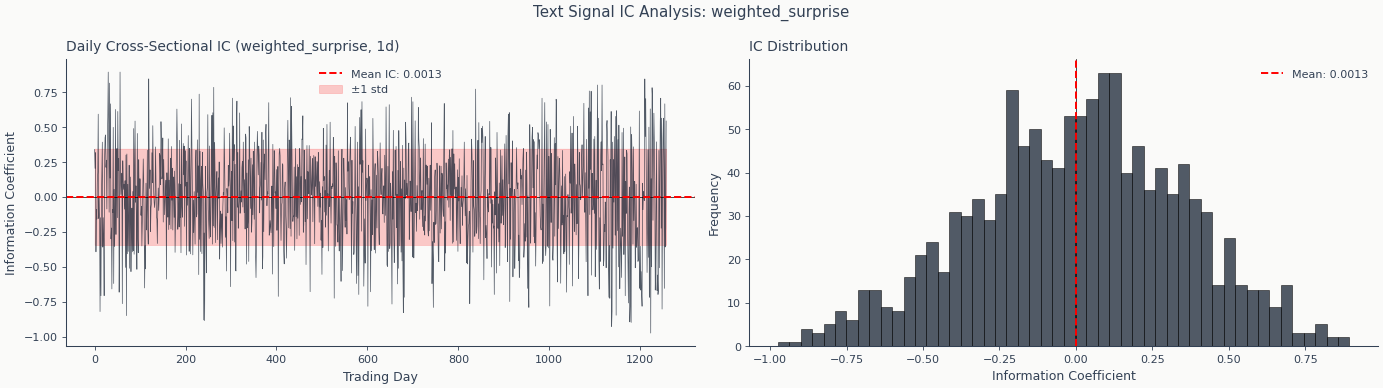

In [12]:
# IC time series for the key signal (weighted_surprise, 1-day horizon)
key_signal = "weighted_surprise"
key_horizon = 1

if key_signal in AVAILABLE_SIGNALS:
    ic_df = daily_ic(
        text_features, key_signal, RET_COL_BY_HORIZON[key_horizon], CONFIG.min_assets_per_day
    )

    if len(ic_df) > 10:
        ic_vals = ic_df["ic"].to_numpy()
        ic_mean = np.mean(ic_vals)
        ic_std = np.std(ic_vals, ddof=1)

        fig, axes = plt.subplots(1, 2, figsize=(14, 4))

        # IC time series
        axes[0].plot(range(len(ic_df)), ic_vals, alpha=0.7, linewidth=0.5)
        axes[0].axhline(0, color="black", linestyle="-", linewidth=0.5)
        axes[0].axhline(ic_mean, color="red", linestyle="--", label=f"Mean IC: {ic_mean:.4f}")
        axes[0].fill_between(
            range(len(ic_df)),
            ic_mean - ic_std,
            ic_mean + ic_std,
            alpha=0.2,
            color="red",
            label="±1 std",
        )
        axes[0].set_xlabel("Trading Day")
        axes[0].set_ylabel("Information Coefficient")
        axes[0].set_title(f"Daily Cross-Sectional IC ({key_signal}, {key_horizon}d)")
        axes[0].legend()

        # IC histogram
        axes[1].hist(ic_vals, bins=50, edgecolor="black", alpha=0.7)
        axes[1].axvline(0, color="black", linestyle="-", linewidth=0.5)
        axes[1].axvline(ic_mean, color="red", linestyle="--", label=f"Mean: {ic_mean:.4f}")
        axes[1].set_xlabel("Information Coefficient")
        axes[1].set_ylabel("Frequency")
        axes[1].set_title("IC Distribution")
        axes[1].legend()

        plt.suptitle(f"Text Signal IC Analysis: {key_signal}")
        plt.tight_layout()
        plt.show()

In [13]:
# Quintile returns for key signal
if key_signal in AVAILABLE_SIGNALS:
    # Compute quintile returns
    d = text_features.select(
        ["timestamp", "symbol", key_signal, RET_COL_BY_HORIZON[key_horizon]]
    ).drop_nulls()

    # Rank and assign quintiles
    d = d.with_columns(
        (
            (pl.col(key_signal).rank(method="average").over("timestamp") - 1)
            / (pl.len().over("timestamp") - 1).clip(lower_bound=1)
        ).alias("rank_pct")
    ).with_columns(
        pl.when(pl.col("rank_pct") < 0.2)
        .then(pl.lit("Q1"))
        .when(pl.col("rank_pct") < 0.4)
        .then(pl.lit("Q2"))
        .when(pl.col("rank_pct") < 0.6)
        .then(pl.lit("Q3"))
        .when(pl.col("rank_pct") < 0.8)
        .then(pl.lit("Q4"))
        .otherwise(pl.lit("Q5"))
        .alias("quintile")
    )

    # Average returns by quintile
    quintile_returns = (
        d.group_by("quintile")
        .agg(
            [
                pl.col(RET_COL_BY_HORIZON[key_horizon]).mean().alias("mean_ret"),
                pl.len().alias("n_obs"),
            ]
        )
        .sort("quintile")
    )

    print(f"\nQuintile Returns ({key_signal}, {key_horizon}d forward return):")
    print(quintile_returns)


Quintile Returns (weighted_surprise, 1d forward return):
shape: (5, 3)
┌──────────┬──────────┬───────┐
│ quintile ┆ mean_ret ┆ n_obs │
│ ---      ┆ ---      ┆ ---   │
│ str      ┆ f64      ┆ u32   │
╞══════════╪══════════╪═══════╡
│ Q1       ┆ 0.001008 ┆ 2574  │
│ Q2       ┆ 0.000409 ┆ 3470  │
│ Q3       ┆ 0.000604 ┆ 4699  │
│ Q4       ┆ 0.000786 ┆ 1735  │
│ Q5       ┆ 0.000221 ┆ 3300  │
└──────────┴──────────┴───────┘


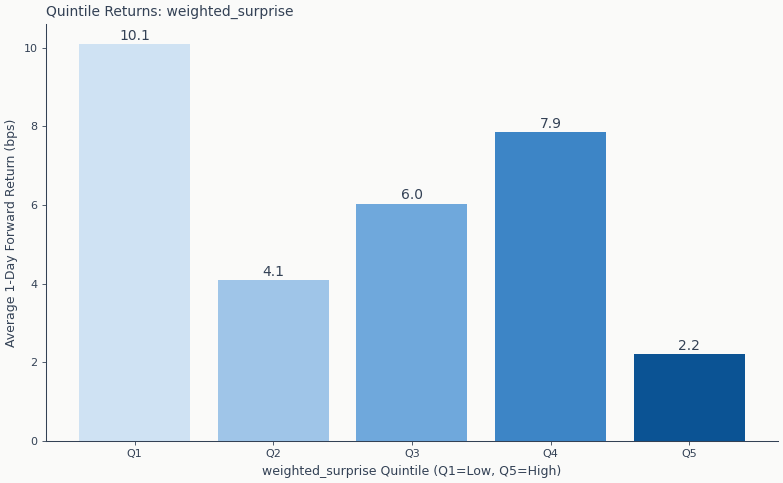

In [14]:
# Plot quintile returns
if key_signal in AVAILABLE_SIGNALS:
    fig, ax = plt.subplots(figsize=(8, 5))

    quintiles = quintile_returns["quintile"].to_list()
    returns_bps = [r * 10000 for r in quintile_returns["mean_ret"].to_list()]

    # Sequential blue gradient for ordinal quintile encoding (greyscale-safe)
    quintile_colors = ["#cfe2f3", "#9fc5e8", "#6fa8dc", "#3d85c6", "#0b5394"]
    bars = ax.bar(quintiles, returns_bps, color=quintile_colors)
    ax.axhline(0, color="black", linestyle="-", linewidth=0.5)
    ax.set_xlabel(f"{key_signal} Quintile (Q1=Low, Q5=High)")
    ax.set_ylabel(f"Average {key_horizon}-Day Forward Return (bps)")
    ax.set_title(f"Quintile Returns: {key_signal}")

    # Add value labels
    for bar, val in zip(bars, returns_bps, strict=False):
        ax.annotate(
            f"{val:.1f}",
            xy=(bar.get_x() + bar.get_width() / 2, bar.get_height()),
            xytext=(0, 3 if val >= 0 else -10),
            textcoords="offset points",
            ha="center",
            fontsize=10,
        )

    plt.tight_layout()
    plt.show()

## 5. Save Results

In [15]:
# Create output directory
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

# Save summary
summary_path = OUTPUT_DIR / "text_signal_summary.parquet"
summary_df.write_parquet(summary_path)
print(f"Saved summary to: {summary_path}")

# Save daily IC series
if daily_ic_rows:
    daily_ic_df = pl.concat(daily_ic_rows, how="vertical_relaxed")
    daily_ic_path = OUTPUT_DIR / "daily_ic.parquet"
    daily_ic_df.write_parquet(daily_ic_path)
    print(f"Saved daily IC to: {daily_ic_path}")

# Save daily long-short series
if daily_ls_rows:
    daily_ls_df = pl.concat(daily_ls_rows, how="vertical_relaxed")
    daily_ls_path = OUTPUT_DIR / "daily_long_short.parquet"
    daily_ls_df.write_parquet(daily_ls_path)
    print(f"Saved daily long-short to: {daily_ls_path}")

Saved summary to: /home/stefan/ml4t/code/08_financial_features/output/text_evaluation/text_signal_summary.parquet
Saved daily IC to: /home/stefan/ml4t/code/08_financial_features/output/text_evaluation/daily_ic.parquet
Saved daily long-short to: /home/stefan/ml4t/code/08_financial_features/output/text_evaluation/daily_long_short.parquet


## Key Takeaways

### Measured signal performance on this evaluation set
1. All four text signals produce 1-day cross-sectional ICIRs within ±0.005
   of zero (weighted_surprise 0.004, sentiment_mean 0.004,
   sentiment_momentum −0.0005, coverage_count −0.004; n≈1,260 dates).
   Per-signal t-stats are all in [−0.2, +0.2] at the 1-day horizon. The
   construction methodology is demonstrated here; the magnitudes do not
   support a ranking claim — none of the four signals is statistically
   distinguishable from zero on this sample.
2. The weighted_surprise quintile sort on 1-day forward returns is
   non-monotonic and Q5 < Q1 (Q1 0.001008, Q2 0.000409, Q3 0.000604,
   Q4 0.000786, Q5 0.000221). The predicted bullish quintile (Q5) earns
   less than the predicted bearish quintile (Q1) — the bullish/bearish
   framing in NB07 is **not** confirmed.
3. ICIR magnitudes here are an order of magnitude or more below the
   ICIR > 0.5 robustness threshold used in NB07's takeaway 4. The
   notebook does not establish tradeability for any of the four signals
   on the 2009-2017 FNSPID 50-ticker subset.

### Evaluation Methodology
- We use the exact dataset from notebook 07 (no label recomputation)
- Forward returns are already aligned to tradable dates with proper lag
- Daily cross-sectional IC avoids temporal autocorrelation issues

### Limitations
1. **Coverage bias**: Notebook 07 drops low-coverage tickers (see its takeaways)
2. **Data sparsity**: News coverage is uneven across stocks and time
3. **Decay**: Text signals may have shorter predictive horizons than momentum

### Next Steps
- Chapter 12: Train ML models on combined feature set (text + price features)
- Chapter 17: Backtest text-enhanced strategies

In [16]:
# Save run metadata for reproducibility
run_metadata = {
    "horizons": list(CONFIG.horizons),
    "min_assets_per_day": CONFIG.min_assets_per_day,
    "quantiles": CONFIG.quantiles,
    "signals_evaluated": AVAILABLE_SIGNALS,
    "n_observations": len(text_features),
    "n_assets": text_features["symbol"].n_unique(),
    "date_range": {
        "min": str(text_features["timestamp"].min()),
        "max": str(text_features["timestamp"].max()),
    },
    "input_file": str(text_features_path),
}

metadata_path = OUTPUT_DIR / "run_metadata.json"
with open(metadata_path, "w") as f:
    json.dump(run_metadata, f, indent=2)
print(f"Run metadata saved to: {metadata_path}")

print("\nText feature evaluation complete")

Run metadata saved to: /home/stefan/ml4t/code/08_financial_features/output/text_evaluation/run_metadata.json

Text feature evaluation complete
